<a href="https://colab.research.google.com/github/BriennedeTarth/AutomatizacionContratosGoogleApps/blob/main/Object_Localization_with_TensorFlow_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Localization with TensorFlow

Created for the Coursera Guided Project: [Object Localization with TensorFlow](https://www.coursera.org/projects/object-localization-tensorflow)

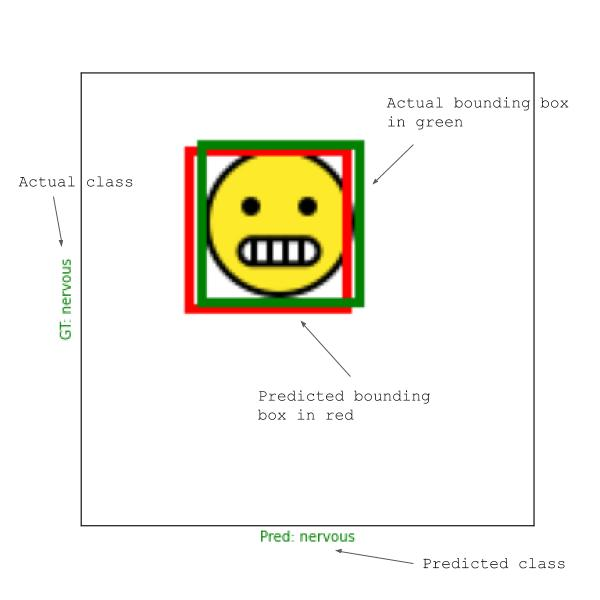

All emojis designed by [OpenMoji](https://openmoji.org/) – the open-source emoji and icon project. License: CC BY-SA 4.0

## Task 2: Download and Visualize Data

In [ ]:
!wget https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
!mkdir emojis
!unzip -q openmoji-72x72-color.zip -d ./emojis
!pip install tensorflow==2.4

--2026-02-23 02:27:06--  https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip [following]
--2026-02-23 02:27:06--  https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/114106318/9532d5d3-3294-49ab-b7f9-5da918081758?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-23T03%3A00%3A42Z&rscd=attachment%3B+filename%3Dopenmoji-72x72-color.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-23T02%3A0

In [ ]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image, ImageDraw
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D, BatchNormalization, Dropout

print('Check if we are using TensorFlow 2.4')
print('Using TensorFlow version', tf.__version__)

Check if we are using TensorFlow 2.4
Using TensorFlow version 2.19.0


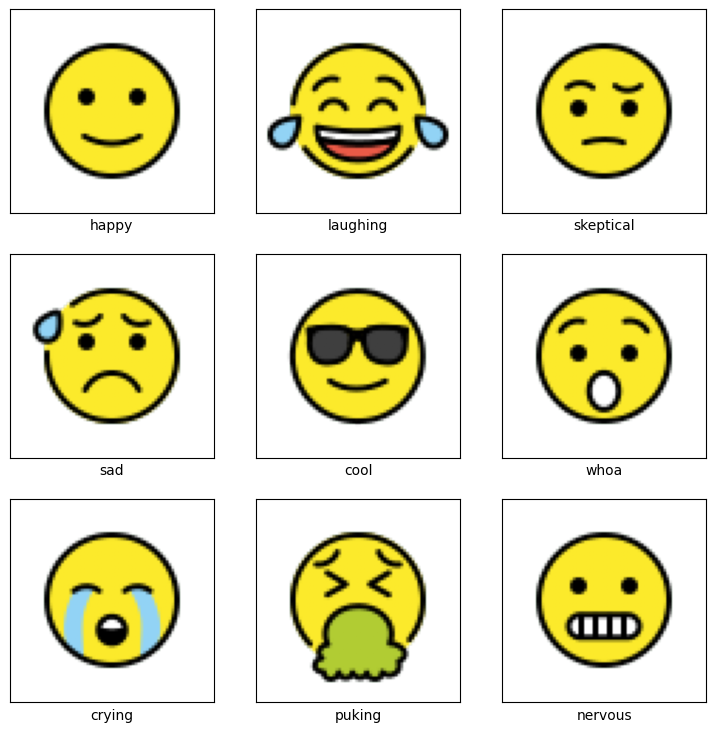

In [ ]:
emojis = {
    0: {'name': 'happy', 'file': '1F642.png'},
    1: {'name': 'laughing', 'file': '1F602.png'},
    2: {'name': 'skeptical', 'file': '1F928.png'},
    3: {'name': 'sad', 'file': '1F630.png'},
    4: {'name': 'cool', 'file': '1F60E.png'},
    5: {'name': 'whoa', 'file': '1F62F.png'},
    6: {'name': 'crying', 'file': '1F62D.png'},
    7: {'name': 'puking', 'file': '1F92E.png'},
    8: {'name': 'nervous', 'file': '1F62C.png'}
}

plt.figure(figsize=(9, 9))

for i, (j, e) in enumerate(emojis.items()):
    plt.subplot(3, 3, i + 1)
    plt.imshow(plt.imread(os.path.join('emojis', e['file'])))
    plt.xlabel(e['name'])
    plt.xticks([])
    plt.yticks([])
plt.show()

## Task 3: Create Examples

In [ ]:
for class_id, values in emojis.items():
    png_file = Image.open(os.path.join('emojis', values['file'])).convert('RGBA')
    png_file.load()
    new_file = Image.new("RGB", png_file.size, (255, 255, 255))
    new_file.paste(png_file, mask=png_file.split()[3])
    emojis[class_id]['image'] = new_file

In [ ]:
emojis

{0: {'name': 'happy',
  'file': '1F642.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 1: {'name': 'laughing',
  'file': '1F602.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 2: {'name': 'skeptical',
  'file': '1F928.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 3: {'name': 'sad',
  'file': '1F630.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 4: {'name': 'cool',
  'file': '1F60E.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 5: {'name': 'whoa',
  'file': '1F62F.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 6: {'name': 'crying',
  'file': '1F62D.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 7: {'name': 'puking',
  'file': '1F92E.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 8: {'name': 'nervous',
  'file': '1F62C.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>}}

In [ ]:
def create_examples():
  class_id = np.random.randint(0, 9)
  image = np.ones((144,144,3))*255
  row = np.random.randint(0, 72)
  col = np.random.randint(0, 72)
  image[row:row+72, col:col+72, :] = np.array(emojis[class_id]['image'])
  return image.astype('uint8'), class_id, (row+10)/144, (col+10)/144

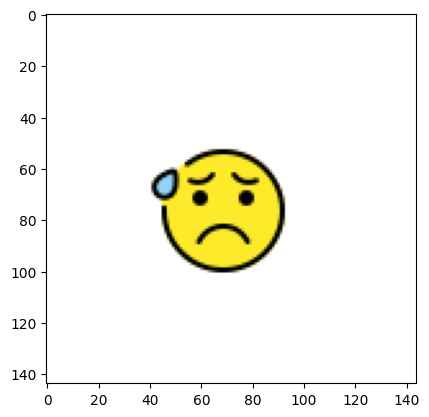

In [ ]:
image, class_id, row, col = create_examples()
plt.imshow(image)

## Task 4: Plot Bounding Boxes

In [ ]:
def plot_bounding_box(image, gt_coords, pred_coords=[],norm=False):
  if norm:
    image *=255.
    image = image.astype('uint8')
  image=Image.fromarray(image)
  draw = ImageDraw.Draw(image)

  row,col= gt_coords
  row *= 144
  col *= 144
  draw.rectangle([col, row, col+52, row+52], outline='green', width=3)

  if len(pred_coords)==2:
    row,col= pred_coords
    row *= 144
    col *= 144
    draw.rectangle([col, row, col+52, row+52], outline='red', width=3)
  return image


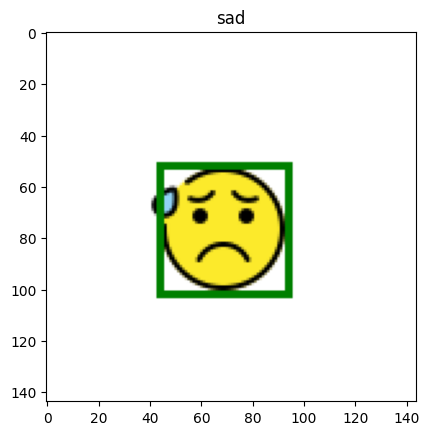

In [ ]:
image=plot_bounding_box(image,gt_coords=[row,col])
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()

## Task 5: Data Generator

In [ ]:
def data_generator(batch_size=10):
  while True:
    x_batch = np.zeros((batch_size,144,144,3))
    y_batch = np.zeros((batch_size,9))
    bbox_batch = np.zeros((batch_size,2), dtype=np.float32) # Changed dtype to float32
    for i in range(batch_size):
      image, class_id, row, col = create_examples()
      x_batch[i] = image/255.
      y_batch[i,class_id] = 1.0
      bbox_batch[i] = np.array([row,col], dtype=np.float32) # Ensure individual elements are also float32
    yield {'image': x_batch}, {'class_out': y_batch, 'box_out': bbox_batch}

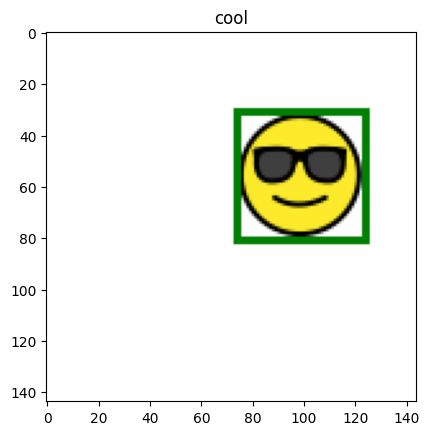

In [ ]:
example, label = next(data_generator(1))
image = example['image'][0]
class_id = np.argmax(label['class_out'][0])
coords = label['box_out'][0]

image = plot_bounding_box(image,coords,norm=True)
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()

## Task 6: Model

In [ ]:
input_ = Input(shape=(144,144,3), name='image')
x = input_
for i in range(0,5):
  n_filters = 2**(4+i)
  x = Conv2D(n_filters,3,activation='relu')(x)
  x = BatchNormalization()(x)
  x = MaxPool2D()(x)

x = Flatten()(x)
x = Dense(256,activation='relu')(x)

class_out = Dense(9,activation='softmax',name='class_out')(x)
box_out = Dense(2,name='box_out')(x)

model = tf.keras.models.Model(input_,[class_out,box_out])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 144, 144,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 142, 142,  │        448 │ image[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 142, 142,  │         64 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 71, 71,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 69, 69,    │      4,640 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 34, 34,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 14, 14,    │     73,856 │ max_pooling2d_12… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 5, 5, 256) │    295,168 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 5, 256) │      1,024 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 2, 2, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1024)      │          0 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 659,819 (2.52 MB)

 Trainable params: 658,827 (2.51 MB)

 Non-trainable params: 992 (3.88 KB)

## Task 7: Custom Metric: IoU

In [ ]:
class IoU(tf.keras.metrics.Metric):
  def __init__(self, **kwargs):
    super(IoU, self).__init__(**kwargs)
    self.iou = self.add_weight(name='iou', initializer='zeros')
    self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
    self.num_ex = self.add_weight(name='num_ex', initializer='zeros')

  def update_state(self, y_true, y_pred, sample_weight=None):
    def get_box(y):
      rows, cols = y[:,0], y[:,1]
      rows, cols = rows*144, cols*144
      #trying to find the bounding box
      y1, y2 = rows, rows+52
      x1, x2 = cols, cols+52
      return x1, y1, x2, y2 # Added return statement

    def get_area(x1, y1, x2, y2):
      return tf.math.abs(x2-x1)*tf.math.abs(y2-y1)

    gt_x1, gt_y1, gt_x2, gt_y2 = get_box(y_true)
    p_x1, p_y1, p_x2, p_y2 = get_box(y_pred)
    #intersections
    i_x1 = tf.maximum(gt_x1, p_x1)
    i_y1 = tf.maximum(gt_y1, p_y1)
    i_x2 = tf.minimum(gt_x2, p_x2)
    i_y2 = tf.minimum(gt_y2, p_y2)

    i_area = get_area(i_x1,i_y1,i_x2, i_y2)
    u_area = get_area(gt_x1,gt_y1,gt_x2, gt_y2)+ get_area(p_x1,p_y1,p_x2, p_y2)-i_area

    iou = tf.math.divide_no_nan(i_area, u_area)
    self.num_ex.assign_add(1)
    self.total_iou.assign_add(tf.reduce_mean(iou))
    # Corrected: Use assign() to update the tf.Variable, not reassign it.
    self.iou.assign(tf.math.divide_no_nan(self.total_iou, self.num_ex))

  def result(self):
    return self.iou

  def reset_states(self):
    # Reset the values of the existing variables to zero
    self.iou.assign(0.)
    self.total_iou.assign(0.)
    self.num_ex.assign(0.)

## Task 8: Compile the Model

In [ ]:
model.compile(
    loss={
        'class_out': 'categorical_crossentropy',
        'box_out': 'mse'
    },
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics={
        'class_out': 'accuracy',
        'box_out': IoU(name='iou')
    }
)

## Task 9: Custom Callback: Model Testing

In [ ]:
def test_model(model, test_datagen):
  example, label = next(test_datagen)
  x = example['image']
  y = label['class_out']
  box = label['box_out']
  pred_y, pred_box = model.predict(x)
  pred_coords = pred_box[0]
  gt_coords = box[0]
  pred_class = np.argmax(pred_y[0])
  image = x[0]
  gt = emojis[np.argmax(y[0])]['name']
  pred_class_name = emojis[pred_class]['name']
  image = plot_bounding_box(image,gt_coords,pred_coords,norm=True)
  color = 'green' if gt==pred_class_name else 'red'
  plt.imshow(image)
  plt.xlabel(f'Pred: {pred_class_name}', color=color)
  plt.ylabel(f'GT: {gt}', color=color)
  plt.xticks([])
  plt.yticks([])

In [ ]:
def test(model):
  test_datagen = data_generator(1)
  plt.figure(figsize=(16,4))

  for i in range(6):
    plt.subplot(1,6,i+1)
    test_model(model, test_datagen)
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


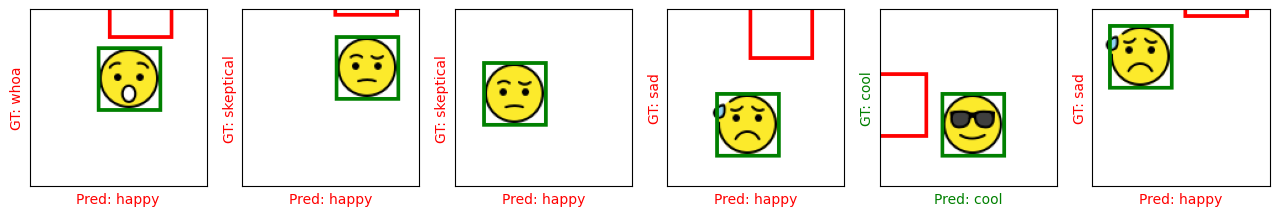

In [ ]:
test(model)

In [ ]:
class ShowTestImages(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    test(self.model)

## Task 10: Model Training

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image
Received: inputs=['Tensor(shape=(None, 144, 144, 3))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


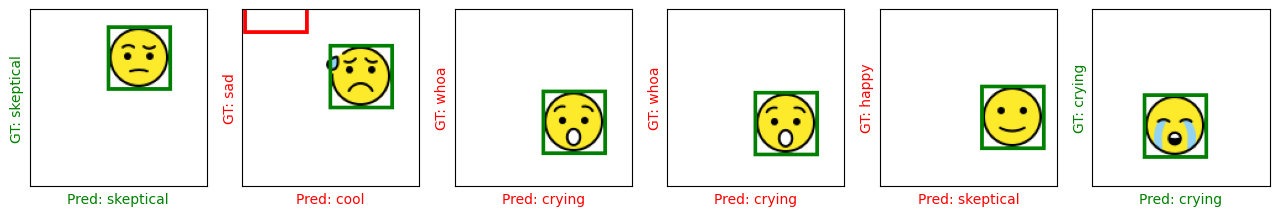

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - box_out_iou: 0.0098 - box_out_loss: 0.1558 - class_out_accuracy: 0.8291 - class_out_loss: 0.3262 - loss: 0.4820
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


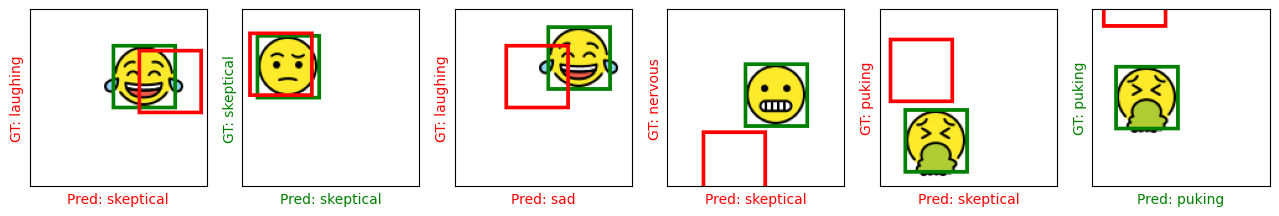

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - box_out_iou: 0.2620 - box_out_loss: 0.0481 - class_out_accuracy: 0.8518 - class_out_loss: 0.2719 - loss: 0.3200
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


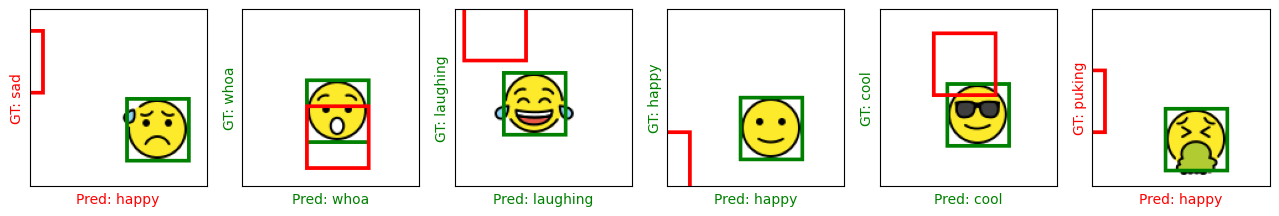

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - box_out_iou: 0.2608 - box_out_loss: 0.0555 - class_out_accuracy: 0.9657 - class_out_loss: 0.0959 - loss: 0.1514
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


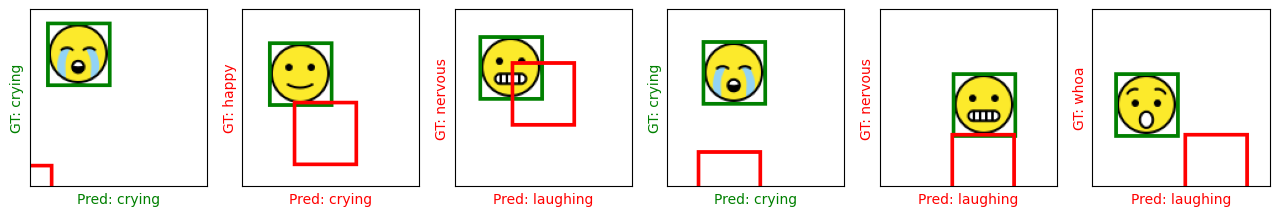

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - box_out_iou: 0.3496 - box_out_loss: 0.0235 - class_out_accuracy: 0.9939 - class_out_loss: 0.0247 - loss: 0.0482
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


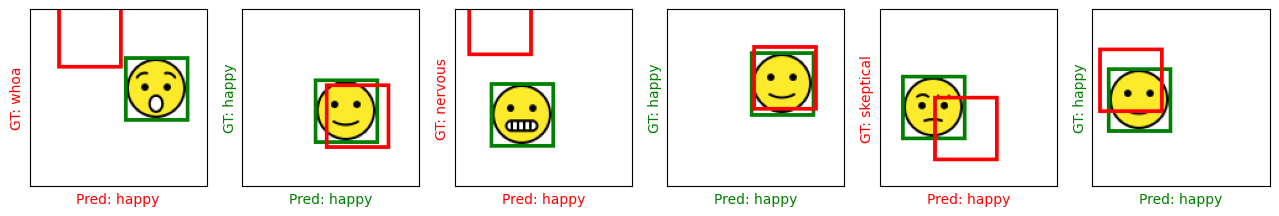

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - box_out_iou: 0.4005 - box_out_loss: 0.0160 - class_out_accuracy: 0.9944 - class_out_loss: 0.0215 - loss: 0.0376
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


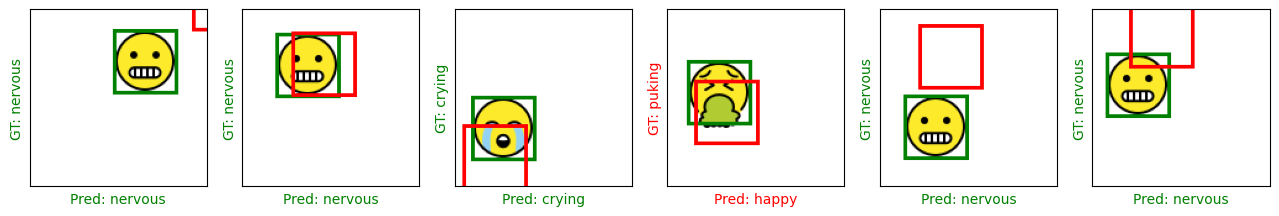

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - box_out_iou: 0.4349 - box_out_loss: 0.0130 - class_out_accuracy: 0.9974 - class_out_loss: 0.0103 - loss: 0.0233
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


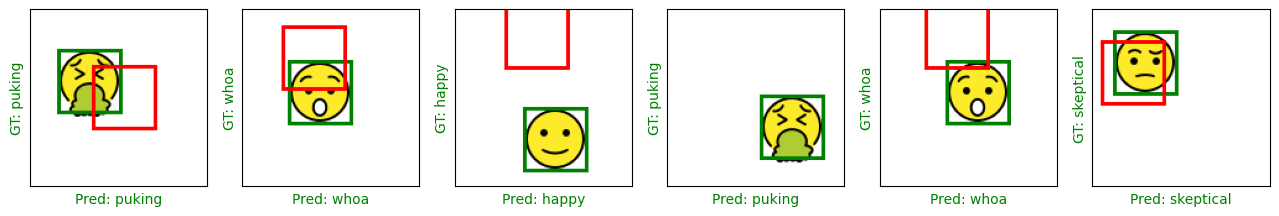

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - box_out_iou: 0.4866 - box_out_loss: 0.0102 - class_out_accuracy: 0.9994 - class_out_loss: 0.0042 - loss: 0.0144
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


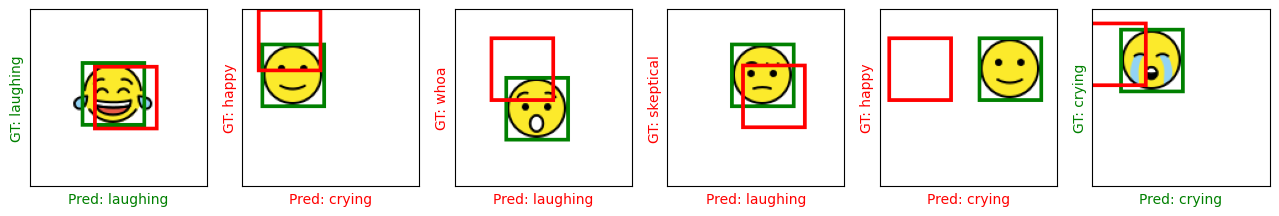

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - box_out_iou: 0.4867 - box_out_loss: 0.0093 - class_out_accuracy: 0.9989 - class_out_loss: 0.0116 - loss: 0.0209
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


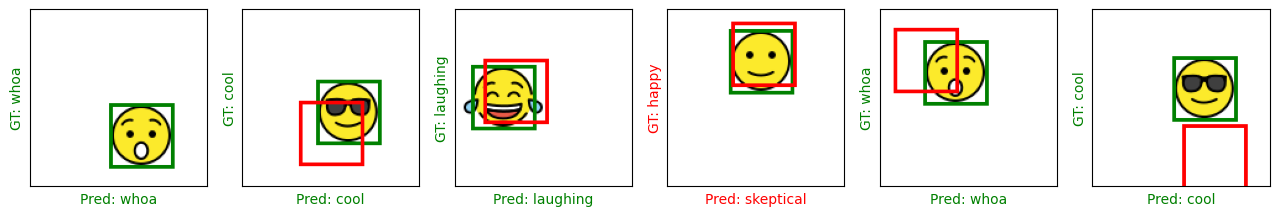

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - box_out_iou: 0.4662 - box_out_loss: 0.0134 - class_out_accuracy: 0.9847 - class_out_loss: 0.0374 - loss: 0.0508
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


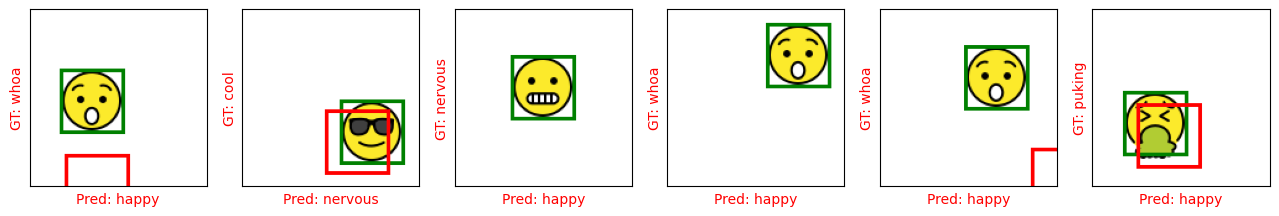

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - box_out_iou: 0.4036 - box_out_loss: 0.0173 - class_out_accuracy: 0.9809 - class_out_loss: 0.0720 - loss: 0.0893


In [ ]:
_ = model.fit(
    data_generator(),
    epochs=10,
    steps_per_epoch=100,
    callbacks=[ShowTestImages(),
               tf.keras.callbacks.EarlyStopping(monitor='box_out_iou', patience=3, mode='max')
               #tf.keras.callbacks.LearningRateScheduler(lf_schedule)
               ]
)